   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

Shape of Dataset: (4521, 17)

Columns:
 Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'ho

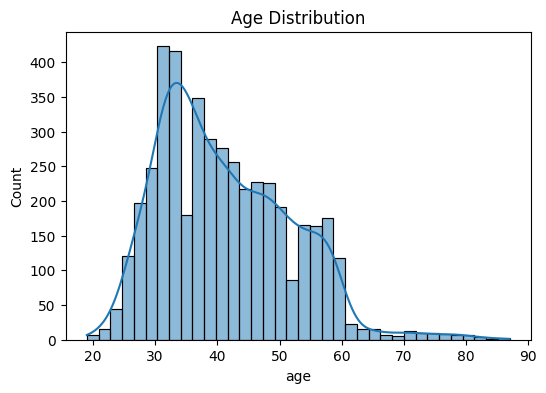

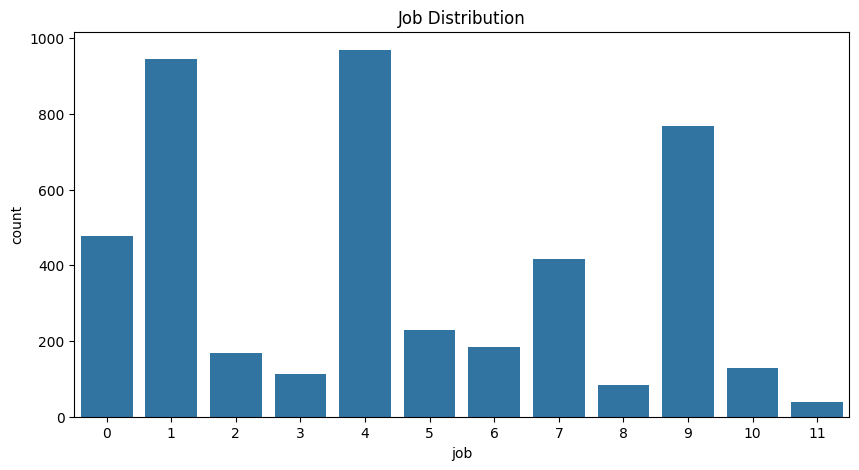

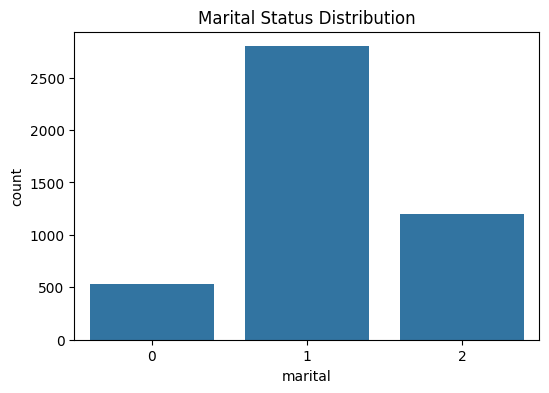

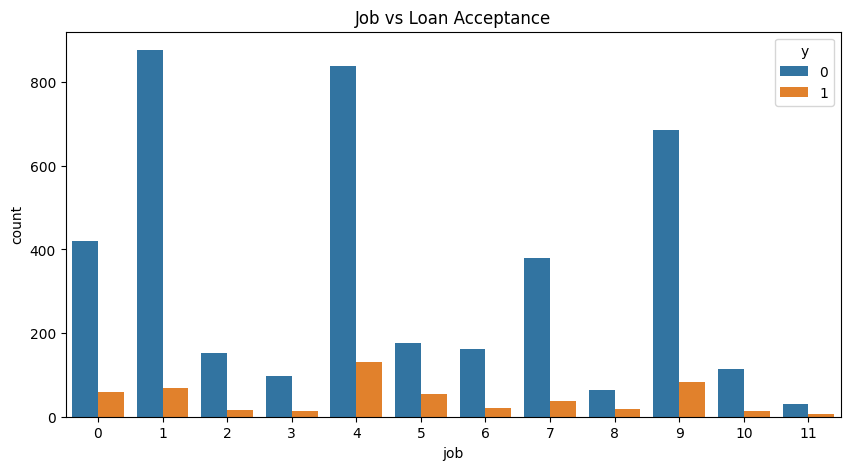

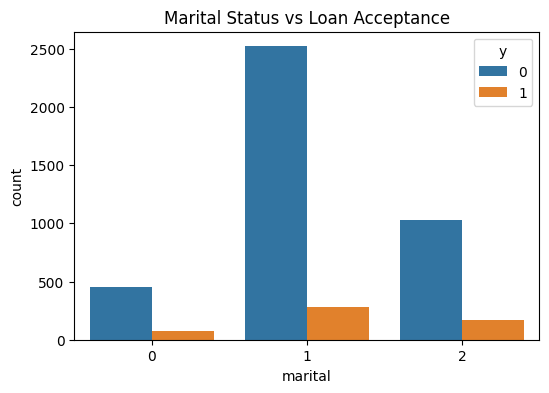

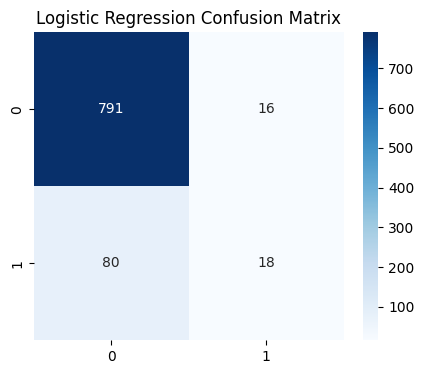

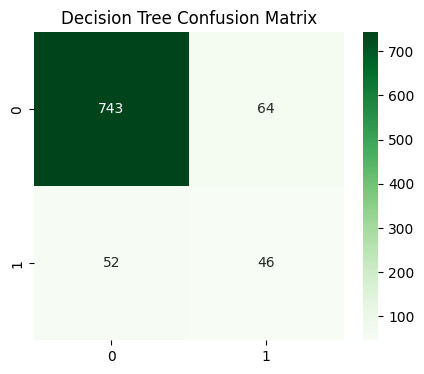


====== Logistic Regression ======
Accuracy: 0.8939226519337017
MAE: 0.10607734806629834
RMSE: 0.3256951766088935

====== Decision Tree ======
Accuracy: 0.8718232044198895
MAE: 0.1281767955801105
RMSE: 0.35801787047591704


In [1]:
# -----------------------------
## Introduction
# -----------------------------
# This project predicts whether a customer is likely to accept
# a personal loan offer using classification models.

# -----------------------------
## Problem Statement
# -----------------------------
# The objective is to analyze customer information and predict
# whether a customer will subscribe to a personal loan offer.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,mean_absolute_error, mean_squared_error,mean_squared_error

# ----------------------------------------
## Dataset Understanding and Description
# ----------------------------------------
# The dataset contains customer demographic and financial information.

df = pd.read_csv("bank.csv", sep=';')

print(df.head())
print("\nShape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nDataset Info:")
df.info()

# Label Encoding
le = LabelEncoder()

# Encode all object/string columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# -----------------------------
## Data Cleaning and Preparation
# -----------------------------
# Checking missing values and preparing data for modeling.

print("\nMissing Values:\n")
print(df.isnull().sum())

# -----------------------------
## Exploratory Data Analysis (EDA)
# -----------------------------
# Visualizing important customer features.

# -----------------------------
# Age Distribution
# -----------------------------

plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# -----------------------------
# Job Distribution
# -----------------------------

plt.figure(figsize=(10,5))
sns.countplot(x='job', data=df)
plt.title("Job Distribution")
plt.show()

# -----------------------------
# Marital Status Distribution
# -----------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='marital', data=df)
plt.title("Marital Status Distribution")
plt.show()

# -----------------------------
# Job vs Loan Acceptance
# -----------------------------
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='y', data=df)
plt.title("Job vs Loan Acceptance")
plt.show()

# -----------------------------
# Marital Status vs Loan Acceptance
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='marital', hue='y', data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()

# -----------------------------
## Model Training and Testing
# -----------------------------
# Training classification models.

# Split data into features and target variable
X = df.drop('y', axis=1)

y = df['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# =========================================================
# MODEL 1: LOGISTIC REGRESSION
# =========================================================

lr_model = LogisticRegression(max_iter=9000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_cm = confusion_matrix(y_test, lr_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

plt.figure(figsize=(5,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# =========================================================
# MODEL 2: DECISION TREE
# =========================================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_cm = confusion_matrix(y_test, dt_pred)

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

plt.figure(figsize=(5,4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# -----------------------------
# Evaluation Metrics
# -----------------------------

print("\n====== Logistic Regression ======")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

print("\n====== Decision Tree ======")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)

# -----------------------------
## Conclusion
# -----------------------------
# In this project, machine learning classification models were used
# to predict whether customers would accept a personal loan offer.
# Logistic Regression achieved better performance with an accuracy
# of approximately 89.5%, while Decision Tree achieved around 87.2%.
# Error metrics also showed that Logistic Regression performed better:
# - Lower MAE (0.105)
# - Lower RMSE (0.324)
# Analysis of customer features such as age, job, and marital status
# helped identify customer groups more likely to accept loan offers.
# Overall, Logistic Regression proved to be the more reliable model
# for predicting personal loan acceptance in this dataset.